In [32]:
!pip install yfinance pandas numpy matplotlib seaborn -q


In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [34]:
bist_hisseler = [
    "AKBNK.IS", "ARCLK.IS", "ASELS.IS", "BIMAS.IS", "EKGYO.IS",
    "EREGL.IS", "FROTO.IS", "GARAN.IS", "HALKB.IS", "ISCTR.IS",
    "KCHOL.IS", "KRDMD.IS", "PETKM.IS",
    "PGSUS.IS", "SAHOL.IS", "SISE.IS", "TAVHL.IS", "TCELL.IS",
    "THYAO.IS", "TKFEN.IS", "TOASO.IS", "TTKOM.IS", "TUPRS.IS",
    "VAKBN.IS", "VESBE.IS", "YKBNK.IS", "SASA.IS", "OYAKC.IS"
]

In [35]:
df_raw = yf.download(
    tickers=bist_hisseler,
    start="2020-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=True
)["Close"]

[*********************100%***********************]  28 of 28 completed


In [36]:
print(f"Tarih araligi: {df_raw.index[0].date()} - {df_raw.index[-1].date()}")
print(f"Boyut: {df_raw.shape[0]} gun x {df_raw.shape[1]} hisse")


Tarih araligi: 2020-01-02 - 2024-12-30
Boyut: 1251 gun x 28 hisse


In [37]:
df_raw.head(3)


Ticker,AKBNK.IS,ARCLK.IS,ASELS.IS,BIMAS.IS,EKGYO.IS,EREGL.IS,FROTO.IS,GARAN.IS,HALKB.IS,ISCTR.IS,...,TAVHL.IS,TCELL.IS,THYAO.IS,TKFEN.IS,TOASO.IS,TTKOM.IS,TUPRS.IS,VAKBN.IS,VESBE.IS,YKBNK.IS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,6.364633,18.671036,5.248263,18.881689,1.326300,3.304402,4.721549,8.890689,6.13,0.940184,...,27.275969,11.245290,14.487193,16.006392,15.254539,5.947456,11.785071,5.56,2.161781,2.105268
2020-01-03,6.193457,18.777222,5.296905,19.313591,1.290695,3.253565,4.610414,8.645918,6.02,0.909903,...,26.866364,11.101121,13.940138,15.353734,15.060865,5.843116,11.573307,5.37,2.213802,2.046788
2020-01-06,5.998939,18.936502,5.369864,19.427683,1.255089,3.220883,4.657561,8.369565,6.03,0.886831,...,26.177483,10.964959,13.256318,14.847928,14.901372,5.674564,11.389168,5.16,2.231143,2.005017


In [38]:
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


Ticker
AKBNK.IS    1
ARCLK.IS    1
ASELS.IS    1
EKGYO.IS    1
GARAN.IS    1
HALKB.IS    1
ISCTR.IS    1
KCHOL.IS    1
KRDMD.IS    1
PETKM.IS    1
SAHOL.IS    1
SISE.IS     1
TAVHL.IS    1
TCELL.IS    1
THYAO.IS    1
TOASO.IS    1
TTKOM.IS    1
TUPRS.IS    1
VAKBN.IS    1
VESBE.IS    1
YKBNK.IS    1
dtype: int64


In [39]:
df_clean = df_raw.ffill().dropna(axis=1, thresh=int(len(df_raw) * 0.8))


In [40]:
print(f"Hisse sayisi: {df_clean.shape[1]}")


Hisse sayisi: 28


In [41]:
print((df_clean.columns))

Index(['AKBNK.IS', 'ARCLK.IS', 'ASELS.IS', 'BIMAS.IS', 'EKGYO.IS', 'EREGL.IS',
       'FROTO.IS', 'GARAN.IS', 'HALKB.IS', 'ISCTR.IS', 'KCHOL.IS', 'KRDMD.IS',
       'OYAKC.IS', 'PETKM.IS', 'PGSUS.IS', 'SAHOL.IS', 'SASA.IS', 'SISE.IS',
       'TAVHL.IS', 'TCELL.IS', 'THYAO.IS', 'TKFEN.IS', 'TOASO.IS', 'TTKOM.IS',
       'TUPRS.IS', 'VAKBN.IS', 'VESBE.IS', 'YKBNK.IS'],
      dtype='object', name='Ticker')


In [42]:
df_returns = np.log(df_clean / df_clean.shift(1)).dropna()


In [43]:
print(f"Getiri matrisi: {df_returns.shape}")


Getiri matrisi: (1250, 28)


In [44]:
print(df_returns.mean().head())


Ticker
AKBNK.IS    0.001824
ARCLK.IS    0.001627
ASELS.IS    0.002107
BIMAS.IS    0.002085
EKGYO.IS    0.001871
dtype: float64


In [45]:
TRADING_DAYS = 252  #yıllık işlem günü

In [46]:
yillik_getiri = df_returns.mean() * TRADING_DAYS
yillik_volatilite = df_returns.std() * np.sqrt(TRADING_DAYS)


In [47]:
risksiz_faiz = 0.05
sharpe = (yillik_getiri - risksiz_faiz) / yillik_volatilite


In [48]:
ozet = pd.DataFrame({
    "Yillik_Getiri_%": (yillik_getiri * 100).round(2),
    "Yillik_Volatilite_%": (yillik_volatilite * 100).round(2),
    "Sharpe_Orani": sharpe.round(3)
}).sort_values("Sharpe_Orani", ascending=False)


In [49]:
print("=" * 55)
print("BIST - YILLIK METRIKLER (2020-2024)")
print("=" * 55)
print(ozet.to_string())
print("=" * 55)
print(f"\nEn yuksek Sharpe: {ozet['Sharpe_Orani'].idxmax()} ({ozet['Sharpe_Orani'].max():.3f})")
print(f"En dusuk Sharpe:  {ozet['Sharpe_Orani'].idxmin()} ({ozet['Sharpe_Orani'].min():.3f})")
print(f"\nEn yuksek getiri: {ozet['Yillik_Getiri_%'].idxmax()} (%{ozet['Yillik_Getiri_%'].max():.1f})")
print(f"En dusuk getiri:  {ozet['Yillik_Getiri_%'].idxmin()} (%{ozet['Yillik_Getiri_%'].min():.1f})")


BIST - YILLIK METRIKLER (2020-2024)
          Yillik_Getiri_%  Yillik_Volatilite_%  Sharpe_Orani
Ticker                                                      
BIMAS.IS            52.53                36.72         1.294
THYAO.IS            59.39                43.93         1.238
FROTO.IS            57.99                45.22         1.172
SAHOL.IS            50.37                39.33         1.154
ASELS.IS            53.10                44.46         1.082
SASA.IS             65.83                57.11         1.065
OYAKC.IS            55.37                47.84         1.053
YKBNK.IS            54.06                47.09         1.042
KCHOL.IS            46.65                40.21         1.036
ISCTR.IS            52.51                46.04         1.032
GARAN.IS            51.95                45.56         1.031
TUPRS.IS            47.51                41.38         1.027
TOASO.IS            49.23                44.76         0.988
SISE.IS             43.99                39.83   

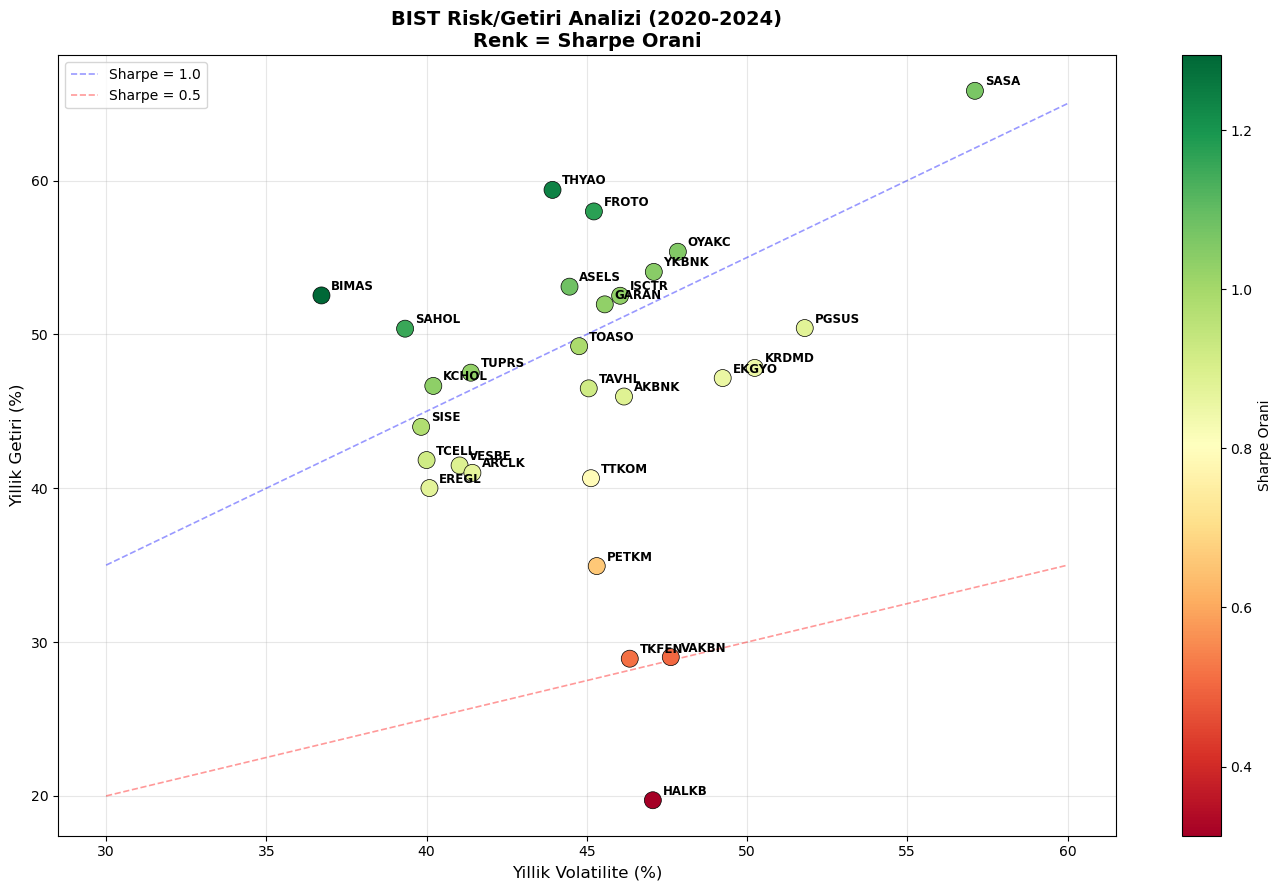

Grafik kaydedildi: bist_risk_getiri.png


In [50]:
#Risk/Getiri Scatter Grafiği
fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    ozet["Yillik_Volatilite_%"],
    ozet["Yillik_Getiri_%"],
    c=ozet["Sharpe_Orani"],
    cmap="RdYlGn",
    s=150,
    edgecolors="black",
    linewidth=0.5,
    zorder=3
)

for ticker, row in ozet.iterrows():
    ad = ticker.replace(".IS", "")
    ax.annotate(
        ad,
        (row["Yillik_Volatilite_%"], row["Yillik_Getiri_%"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8.5,
        fontweight="bold"
    )

vol_range = np.linspace(30, 60, 100)
ax.plot(vol_range, risksiz_faiz * 100 + 1.0 * vol_range, 
        "b--", alpha=0.4, linewidth=1.2, label="Sharpe = 1.0")
ax.plot(vol_range, risksiz_faiz * 100 + 0.5 * vol_range, 
        "r--", alpha=0.4, linewidth=1.2, label="Sharpe = 0.5")

plt.colorbar(scatter, ax=ax, label="Sharpe Orani")
ax.set_xlabel("Yillik Volatilite (%)", fontsize=12)
ax.set_ylabel("Yillik Getiri (%)", fontsize=12)
ax.set_title("BIST Risk/Getiri Analizi (2020-2024)\nRenk = Sharpe Orani", 
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bist_risk_getiri.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: bist_risk_getiri.png")

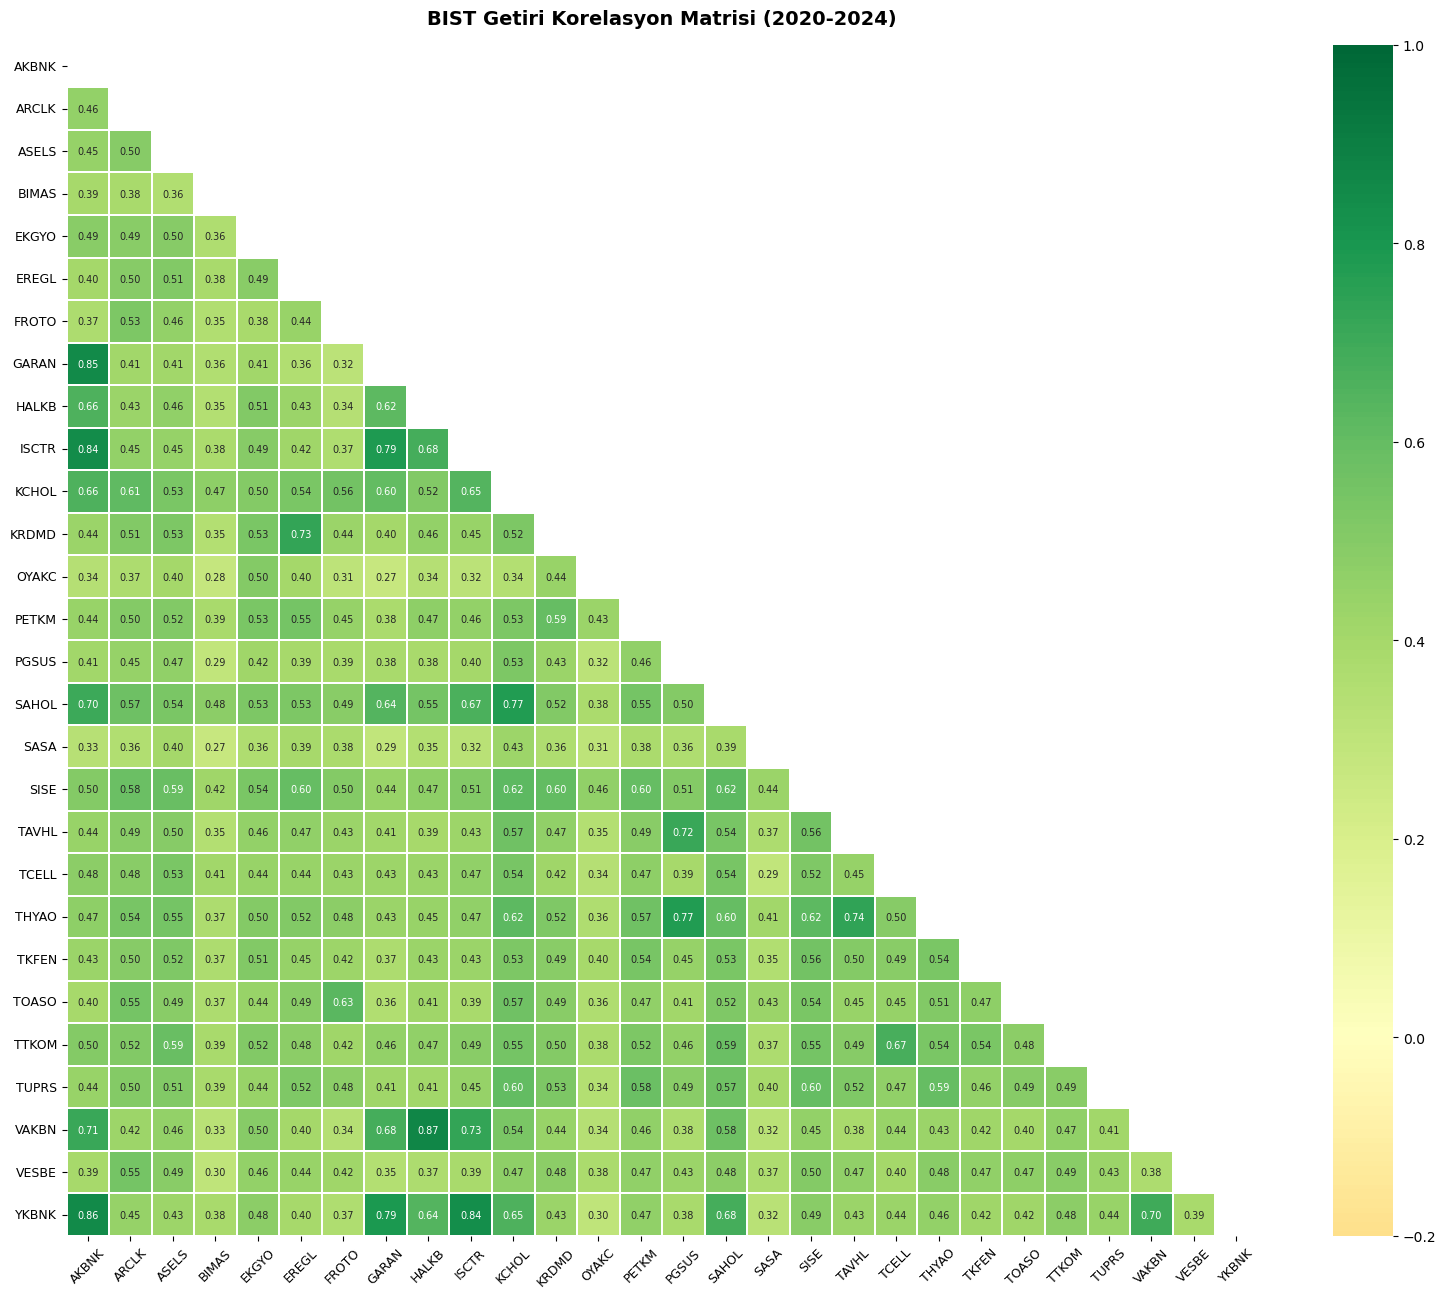


En yuksek korelasyon (Top 5):
VAKBN  HALKB    0.866607
YKBNK  AKBNK    0.858395
GARAN  AKBNK    0.852359
ISCTR  AKBNK    0.844890
YKBNK  ISCTR    0.840003

En dusuk korelasyon (Bottom 5):
SASA   BIMAS    0.269580
OYAKC  GARAN    0.273360
       BIMAS    0.276841
PGSUS  BIMAS    0.288440
SASA   GARAN    0.289571


In [51]:
#Korelasyon Matrisi

df_returns_k = df_returns.copy()
df_returns_k.columns = [c.replace(".IS", "") for c in df_returns_k.columns]

corr_matrix = df_returns_k.corr()

fig, ax = plt.subplots(figsize=(16, 13))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-0.2,
    vmax=1.0,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 7},
    ax=ax
)

ax.set_title("BIST Getiri Korelasyon Matrisi (2020-2024)", 
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig("bist_korelasyon.png", dpi=150, bbox_inches="tight")
plt.show()

corr_pairs = corr_matrix.where(mask == False).stack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

print("\nEn yuksek korelasyon (Top 5):")
print(corr_pairs.sort_values(ascending=False).head(5).to_string())
print("\nEn dusuk korelasyon (Bottom 5):")
print(corr_pairs.sort_values(ascending=True).head(5).to_string())

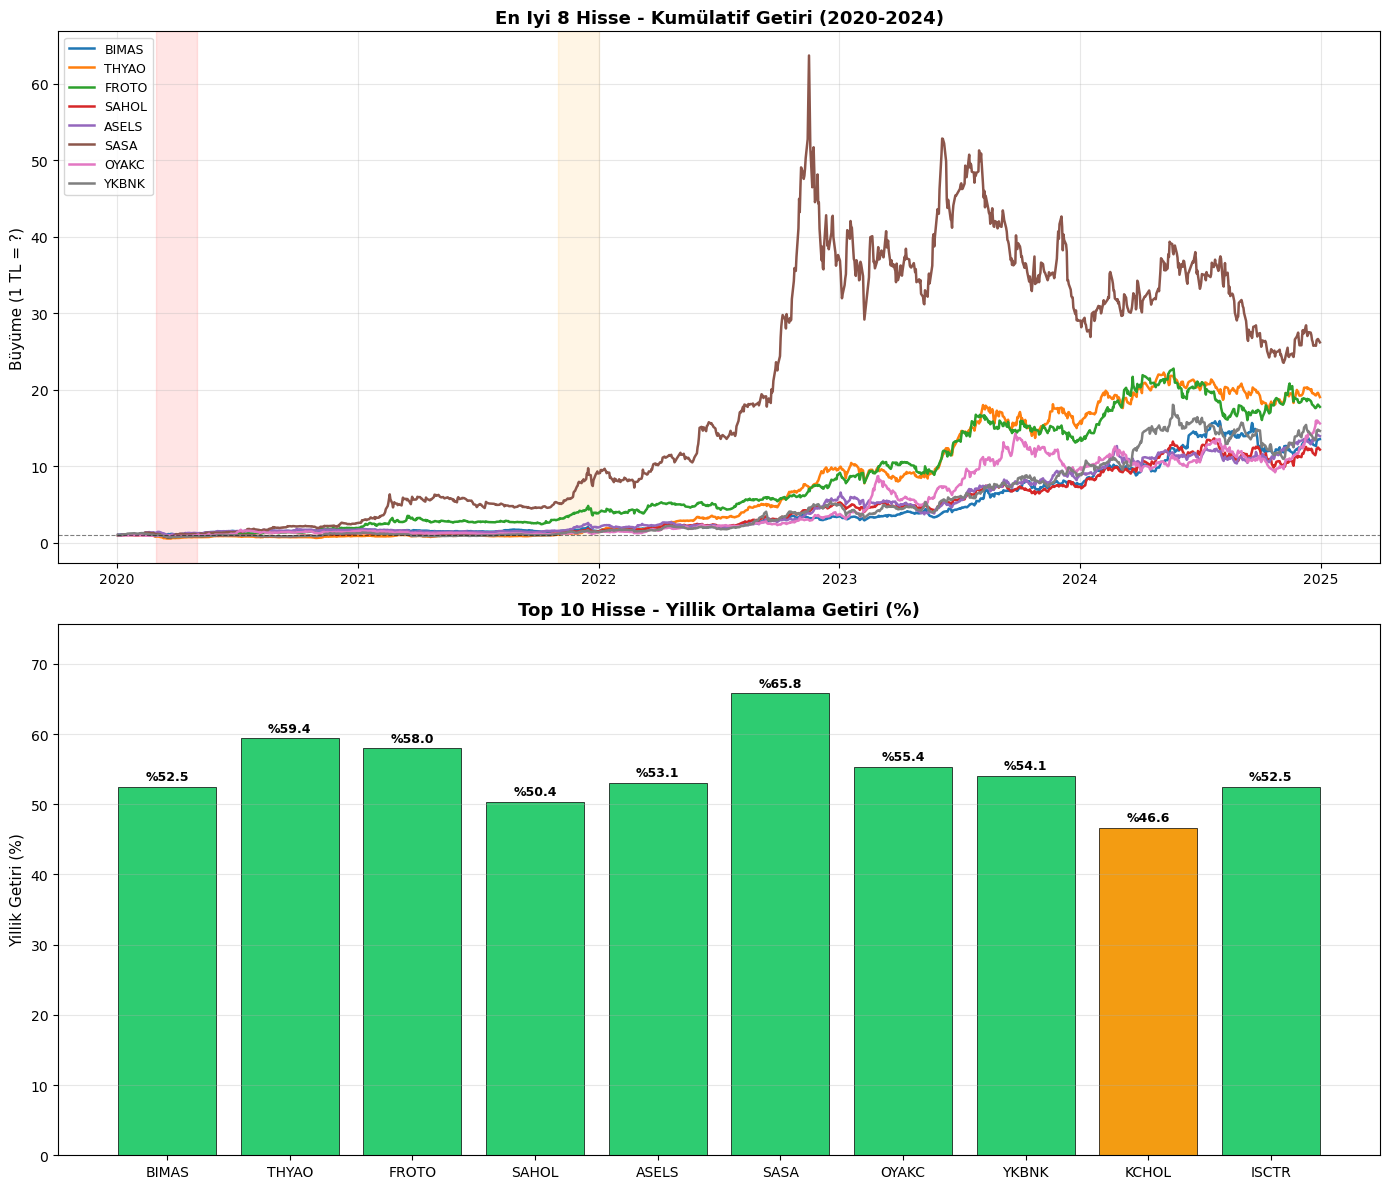

Grafik kaydedildi!


In [52]:
#Kümülatif Getiri Grafiği

top8 = ozet.head(8).index.tolist()
top8_k = [c.replace(".IS", "") for c in top8]

df_cum = (1 + np.exp(df_returns[top8]) - 1).cumprod()
df_cum.columns = top8_k

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

for col in top8_k:
    ax1.plot(df_cum.index, df_cum[col], linewidth=1.8, label=col)

ax1.axhline(y=1, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_title("En Iyi 8 Hisse - Kumülatif Getiri (2020-2024)", 
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Büyüme (1 TL = ?)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

ax1.axvspan("2020-03-01", "2020-05-01", alpha=0.1, color="red", label="COVID")
ax1.axvspan("2021-11-01", "2022-01-01", alpha=0.1, color="orange", label="TL Krizi")

getiri_bar = ozet.head(10)["Yillik_Getiri_%"].copy()
getiri_bar.index = [i.replace(".IS", "") for i in getiri_bar.index]
colors = ["#2ecc71" if x > 50 else "#f39c12" if x > 40 else "#e74c3c" 
          for x in getiri_bar.values]

bars = ax2.bar(getiri_bar.index, getiri_bar.values, color=colors, 
               edgecolor="black", linewidth=0.5)

for bar, val in zip(bars, getiri_bar.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"%{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_title("Top 10 Hisse - Yillik Ortalama Getiri (%)", 
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Yillik Getiri (%)", fontsize=11)
ax2.set_ylim(0, max(getiri_bar.values) * 1.15)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("bist_getiri_analiz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi!")



## Değerlendirme

### SASA
2022'de 60x'e çıkmış sonra dramatik çöküş — spekülatif balon klasiği

### BIMAS, THYAO, FROTO
İstikrarlı ve sürekli büyüme — kaliteli hisseler

### Kriz Dönemleri
COVID ve TL Krizi dönemlerinde tüm hisseler etkilenmiş ama toparlamış


In [53]:
#Özet Rapor

print("=" * 60)
print("   BIST GETIRI ANALIZI - OZET RAPOR (2020-2024)")
print("=" * 60)

print("VERİ OZETI")
print(f"  Analiz edilen hisse: {df_clean.shape[1]}")
print(f"  Tarih araligi:       2020-01-01 - 2024-12-31")
print(f"  Islem gunu:          {len(df_returns)}")
print(f"  Risksiz faiz:        %{risksiz_faiz*100:.0f} (dolar bazli)")

print("EN IYI 5 HİSSE (Sharpe Oranina Gore)")
print("-" * 45)
for i, (ticker, row) in enumerate(ozet.head(5).iterrows(), 1):
    ad = ticker.replace(".IS", "")
    print(f"  {i}. {ad:8s} | Getiri: %{row['Yillik_Getiri_%']:5.1f} | "
          f"Vol: %{row['Yillik_Volatilite_%']:5.1f} | Sharpe: {row['Sharpe_Orani']:.3f}")

print("EN KOTU 5 HİSSE (Sharpe Oranina Gore)")
print("-" * 45)
for i, (ticker, row) in enumerate(ozet.tail(5).iterrows(), 1):
    ad = ticker.replace(".IS", "")
    print(f"  {i}. {ad:8s} | Getiri: %{row['Yillik_Getiri_%']:5.1f} | "
          f"Vol: %{row['Yillik_Volatilite_%']:5.1f} | Sharpe: {row['Sharpe_Orani']:.3f}")

print("KORELASYON BULGULARI")
print("-" * 45)
print("  En yuksek korelasyon (cesitlendirme olmaz):")
for (t1, t2), val in corr_pairs.sort_values(ascending=False).head(3).items():
    print(f"    {t1.replace('.IS','')} - {t2.replace('.IS','')}: {val:.3f}")

print("  En dusuk korelasyon (ideal cesitlendirme):")
for (t1, t2), val in corr_pairs.sort_values(ascending=True).head(3).items():
    print(f"    {t1.replace('.IS','')} - {t2.replace('.IS','')}: {val:.3f}")

print("YATIRIM ONERILERI")
print("-" * 45)
print("  1. BIMAS: En iyi risk/getiri dengesi (Sharpe 1.29)")
print("  2. THYAO: Guclu buyume, makul risk (Sharpe 1.24)")  
print("  3. Banka hisseleri cok korele — portfoyden")
print("     sadece 1-2 tanesini sec!")
print("  4. SASA gibi yuksek volatilite hisselerden")
print("     uzak dur ya da kucuk agirlik ver.")
print("  5. BIMAS + THYAO + ASELS + FROTO kombinasyonu")
print("     ideal dusuk-korelasyonlu portfoy olusturur.")

print("KAYDEDILEN DOSYALAR")
print("  - bist_risk_getiri.png")
print("  - bist_korelasyon.png")
print("  - bist_getiri_analiz.png")


   BIST GETIRI ANALIZI - OZET RAPOR (2020-2024)
VERİ OZETI
  Analiz edilen hisse: 28
  Tarih araligi:       2020-01-01 - 2024-12-31
  Islem gunu:          1250
  Risksiz faiz:        %5 (dolar bazli)
EN IYI 5 HİSSE (Sharpe Oranina Gore)
---------------------------------------------
  1. BIMAS    | Getiri: % 52.5 | Vol: % 36.7 | Sharpe: 1.294
  2. THYAO    | Getiri: % 59.4 | Vol: % 43.9 | Sharpe: 1.238
  3. FROTO    | Getiri: % 58.0 | Vol: % 45.2 | Sharpe: 1.172
  4. SAHOL    | Getiri: % 50.4 | Vol: % 39.3 | Sharpe: 1.154
  5. ASELS    | Getiri: % 53.1 | Vol: % 44.5 | Sharpe: 1.082
EN KOTU 5 HİSSE (Sharpe Oranina Gore)
---------------------------------------------
  1. TTKOM    | Getiri: % 40.6 | Vol: % 45.1 | Sharpe: 0.790
  2. PETKM    | Getiri: % 34.9 | Vol: % 45.3 | Sharpe: 0.661
  3. TKFEN    | Getiri: % 28.9 | Vol: % 46.3 | Sharpe: 0.516
  4. VAKBN    | Getiri: % 29.0 | Vol: % 47.6 | Sharpe: 0.504
  5. HALKB    | Getiri: % 19.7 | Vol: % 47.1 | Sharpe: 0.313
KORELASYON BULGULARI
--